# **Artificial Intelligence & Machine Learning - Task 2**

## **Feature Engineering, Model Optimization & Performance Comparison**

**NAME: NIVETHA SANTHOSH**

Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ignore warnings
import warnings
warnings.filterwarnings("ignore")

Step 2: Load the Dataset

In [5]:
data = fetch_california_housing(as_frame=True)

df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)

df


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [6]:
print("First 5 rows of dataset:")
print(df.head())

First 5 rows of dataset:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  HousePrice  
0    -122.23       4.526  
1    -122.22       3.585  
2    -122.24       3.521  
3    -122.25       3.413  
4    -122.25       3.422  


In [7]:
print("\nDataset Shape:")
print(df.shape)


Dataset Shape:
(20640, 9)


In [8]:
print("\nColumn Names:")
print(df.columns)


Column Names:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'HousePrice'],
      dtype='object')


In [9]:
print("\nData Types:")
print(df.dtypes)


Data Types:
MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
HousePrice    float64
dtype: object


In [10]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64


Step 3: Separate Features and Target Variable

In [11]:
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

print("\nFeature Matrix Shape:", X.shape)
print("Target Vector Shape:", y.shape)



Feature Matrix Shape: (20640, 8)
Target Vector Shape: (20640,)


Step 4: Feature Scaling

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nFeature scaling completed.")
print("Scaled feature sample:")
print(X_scaled[:5])



Feature scaling completed.
Scaled feature sample:
[[ 2.34476576  0.98214266  0.62855945 -0.15375759 -0.9744286  -0.04959654
   1.05254828 -1.32783522]
 [ 2.33223796 -0.60701891  0.32704136 -0.26333577  0.86143887 -0.09251223
   1.04318455 -1.32284391]
 [ 1.7826994   1.85618152  1.15562047 -0.04901636 -0.82077735 -0.02584253
   1.03850269 -1.33282653]
 [ 0.93296751  1.85618152  0.15696608 -0.04983292 -0.76602806 -0.0503293
   1.03850269 -1.33781784]
 [-0.012881    1.85618152  0.3447108  -0.03290586 -0.75984669 -0.08561576
   1.03850269 -1.33781784]]


Step 5: Train-Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("\nTraining set size:", X_train.shape)
print("Testing set size:", X_test.shape)



Training set size: (16512, 8)
Testing set size: (4128, 8)


Step 6: Train Multiple Models

In [14]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42)
}

results = {}
predictions_dict = {}

print("\nModel Training and Evaluation:")
print("-" * 40)

for name, model in models.items():
    # Train model
    model.fit(X_train, y_train)

    # Predict on test data
    y_pred = model.predict(X_test)
    predictions_dict[name] = y_pred

    # Evaluate
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Store results
    results[name] = {
        "RMSE": rmse,
        "R2 Score": r2
    }

    print(f"{name}")
    print(f"RMSE     : {rmse:.4f}")
    print(f"R2 Score : {r2:.4f}")
    print("-" * 40)



Model Training and Evaluation:
----------------------------------------
Linear Regression
RMSE     : 0.7456
R2 Score : 0.5758
----------------------------------------
Ridge Regression
RMSE     : 0.7456
R2 Score : 0.5758
----------------------------------------
Decision Tree
RMSE     : 0.7242
R2 Score : 0.5997
----------------------------------------


Step 7: Create Model Comparison Table

In [15]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="R2 Score", ascending=False)

print("\nModel Comparison Table:")
print(results_df)



Model Comparison Table:
                       RMSE  R2 Score
Decision Tree      0.724234  0.599732
Ridge Regression   0.745554  0.575819
Linear Regression  0.745581  0.575788


Step 8: Select Best Model

In [16]:
best_model_name = results_df.index[0]
best_model = models[best_model_name]
best_predictions = predictions_dict[best_model_name]

print(f"\nBest Model: {best_model_name}")
print(f"Best RMSE: {results_df.iloc[0]['RMSE']:.4f}")
print(f"Best R2 Score: {results_df.iloc[0]['R2 Score']:.4f}")



Best Model: Decision Tree
Best RMSE: 0.7242
Best R2 Score: 0.5997


Step 9: Visual Performance Validation

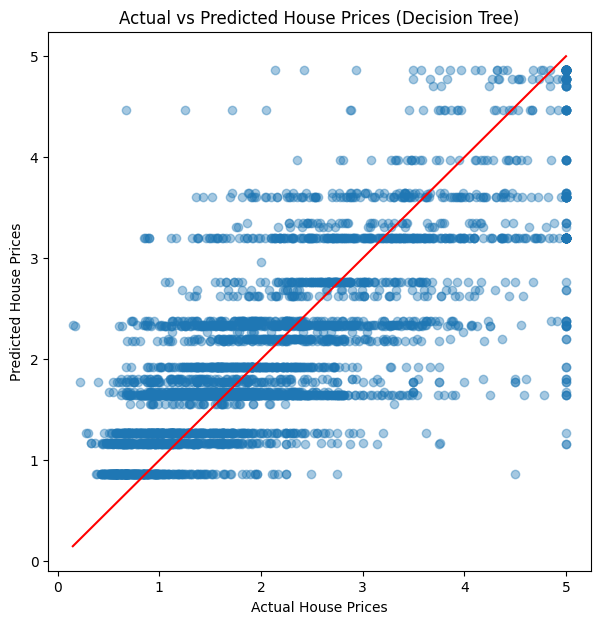

In [17]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, best_predictions, alpha=0.4)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title(f"Actual vs Predicted House Prices ({best_model_name})")

# Reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.show()


Step 10: Optional - Save Results Table to CSV

In [18]:
results_df.to_csv("model_comparison_results.csv")
print("\nModel comparison table saved as 'model_comparison_results.csv'")


# Step 11: Final Conclusion Print
print("\nFinal Conclusion:")
print(f"The best-performing model is {best_model_name} based on highest R2 Score and lowest RMSE among the tested models.")


Model comparison table saved as 'model_comparison_results.csv'

Final Conclusion:
The best-performing model is Decision Tree based on highest R2 Score and lowest RMSE among the tested models.
